<div class="alert alert-block alert-success">

# App 1: 数据预处理与数据集构建 (Data Preprocessing & Dataset Construction)

**项目:** FIT5196 A1 (Extended Part)  
**模块:** App 1 - 多模态文本分类器 (评分预测)  
**作者:** Zihan Yin
**日期:** 2025.11.21

</div>

**概览 (Overview):**
本 Notebook 是专为 **App 1 (多模态分类器)** 设计的 **ETL (抽取、转换、加载)** 管道。

虽然 Task 1 提供了通用的清洗后数据集 (`GroupALL`)，但本模块将其进一步提炼为适合深度学习的高质量、平衡且支持多模态的数据格式。本流程处理了关键任务，包括全局图片资产的获取、模态过滤以及为后续训练阶段准备的类别平衡。

<div class="alert alert-block alert-info">

## 预处理管道架构 (Preprocessing Pipeline Architecture)

为了从原始数据过渡到可训练格式，本 Notebook 实施了以下 5 步管道：

1.  **配置与环境设置:** 建立稳健的运行环境，支持 UNC 路径 (解决 Windows 路径长度限制)，并定义全局资产的统一目录结构。
2.  **数据加载与模态过滤:** 加载 Feather 格式的完整数据 (570万+ 行) 并剔除“幽灵数据” (既无文本也无图片的行)。关键点在于：我们保留了纯文本评论以防止信息丢失。
3.  **全局图片获取 (下载器):** 实现多线程爬虫，从 Google Maps User Content CDN 下载 **约 50 万张图片**。
    * *注:* 图片作为 **全局资产 (Global Asset)** 存储在 `../01_data/03_images_raw/` 中，与特定 App 解耦，允许后续模块 (如 App 5) 复用。
4.  **类别平衡策略:** 针对严重的标签不平衡 (长尾分布) 问题，采用 **“温和欠采样” (Mild Undersampling)** 策略。我们将 5 星样本保留为次大类别数量的 **3倍**，既保持了数据多样性，又防止模型产生严重偏见。
5.  **划分与序列化:** 将平衡后的数据集按 **训练集 (80%)**、**验证集 (10%)** 和 **测试集 (10%)** 进行分层划分 (Stratified Split)，并保存为高性能的 Feather 文件。

</div>

## 1. 路径配置与环境设置 (Path Configuration)
**目标:** 定义输入/输出路径并处理操作系统限制。
* **UNC 路径:** 使用 `\\?\` 前缀绕过 Windows 260 字符的路径长度限制。
* **目录结构:** 自动创建用于存储全局图片资产和训练数据的目录。

In [1]:
import pandas as pd
import numpy as np
import os
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import ast

# ==========================================
# 1. 路径与配置 (Path Configuration)
# ==========================================

# 基础路径配置 (基于 Notebook 所在位置: 04_extended_app/App1_Multimodal_Text_Classification/)
INPUT_DATA_PATH = '../../01_data/02_data_wrangled/Task1_for_GroupALL.ftr'
IMAGE_OUTPUT_DIR = '../../01_data/03_images_raw/'  # 图片存储位置
DATA_OUTPUT_DIR = '../../01_data/04_data_for_app1/' # 训练数据输出位置

# Windows UNC 路径处理 (解决路径过长问题)
def get_unc_path(path):
    abs_path = os.path.abspath(path)
    if os.name == 'nt' and not abs_path.startswith('\\\\?\\'):
        return '\\\\?\\' + abs_path.replace('/', '\\')
    return abs_path

# 确保输出目录存在
os.makedirs(get_unc_path(IMAGE_OUTPUT_DIR), exist_ok=True)
os.makedirs(get_unc_path(DATA_OUTPUT_DIR), exist_ok=True)

# 绘图风格设置
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

print(f"工作目录: {os.getcwd()}")
print(f"数据输入路径: {get_unc_path(INPUT_DATA_PATH)}")
print(f"图片保存路径: {get_unc_path(IMAGE_OUTPUT_DIR)}")

c:\Users\zyyin1\anaconda3\envs\python_for_data_analysis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


工作目录: e:\05_YZH_DS\02_Monash_DS\2024_S2_FIT5196_Data wrangling\5. assessments\FIT5196 assignment 1\04_github_submission\2024-07-Google-Map-Review-Analysis-and-Machine-Learning\04_extended_app\App1_Multimodal_Text_Classification
数据输入路径: \\?\e:\05_YZH_DS\02_Monash_DS\2024_S2_FIT5196_Data wrangling\5. assessments\FIT5196 assignment 1\04_github_submission\2024-07-Google-Map-Review-Analysis-and-Machine-Learning\01_data\02_data_wrangled\Task1_for_GroupALL.ftr
图片保存路径: \\?\e:\05_YZH_DS\02_Monash_DS\2024_S2_FIT5196_Data wrangling\5. assessments\FIT5196 assignment 1\04_github_submission\2024-07-Google-Map-Review-Analysis-and-Machine-Learning\01_data\03_images_raw


## 2. 数据加载与基础清洗 (Loading & Cleaning)
**目标:** 加载全量数据集并执行基于模态的过滤。
* **输入:** `Task1_for_GroupALL.ftr` (Task 1 通用预处理步骤的产出)。
* **过滤逻辑:**  
    * 剔除 `review_rating` 缺失的行 (无标签)。 
    * 剔除 `len_review_text == 0` 且 `n_pictures == 0` 的行 (无信息废数据)。
    * *注:* 我们特意保留了有文本但无图片的评论，以最大化数据利用率。

In [ ]:
# ==========================================
# 2. 数据加载与基础清洗 (Loading & Cleaning)
# ==========================================

print("\n[Step 1] Loading Data...")
df = pd.read_feather(get_unc_path(INPUT_DATA_PATH))

# Checkpoint A: 原始数据
print(f"CheckPoint A - 原始数据行数: {len(df)}")

# 剔除无用列
cols_to_drop = ['name', 'time', 'review_text_pre_translated', 'resp_text', 'resp_text_pre_translated', 'if_response']
# 仅剔除存在的列，防止报错
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# 确保关键列存在 (Feature Engineering)
# 重新计算 len_review_text (Word Count)
if 'review_text' in df.columns:
    df['len_review_text'] = df['review_text'].fillna("").apply(lambda x: len(str(x).split()))

# 重新计算 n_pictures (List Length)
# 注意：pics 列在 Feather 中通常是序列化的 JSON 字符串或 None
def safe_count_pics(x):
    if x is None: return 0
    if isinstance(x, str):
        try:
            # 尝试解析 JSON 列表
            return len(json.loads(x.replace("'", '"'))) # 替换单引号以符合 JSON 规范
        except:
            return 0
    return 0

# 如果 n_pictures 不存在或需要刷新，建议重新计算一次以保准
# 这里我们假设 Task 1 已经生成了 n_pictures，如果没有则取消下方注释
df['n_pictures'] = df['pics'].apply(safe_count_pics)

# 过滤逻辑 1: 剔除 review_rating 为空的行
initial_len = len(df)
df = df.dropna(subset=['review_rating'])
print(f"  - 因 review_rating 为空删除: {initial_len - len(df)} 行")

# 过滤逻辑 2: 剔除无信息行 (无文本 且 无图片)
before_filter_len = len(df)
df = df[~((df['len_review_text'] == 0) & (df['n_pictures'] == 0))]
print(f"  - 因 (无文本 & 无图片) 删除: {before_filter_len - len(df)} 行")

# Checkpoint B: 清洗后
print(f"CheckPoint B - 清洗后数据行数: {len(df)}")


[Step 1] Loading Data...
CheckPoint A - 原始数据行数: 5767463
  - 因 review_rating 为空删除: 10383 行
  - 因 (无文本 & 无图片) 删除: 2396592 行
CheckPoint B - 清洗后数据行数: 3360488


## 3. 图片下载器 (Image Downloader)

### 3.1 定义下载函数 (Downloader Functions)
**目标:** 定义获取图片资产的核心逻辑。
* **安全机制:** 包含 `User-Agent` 请求头以模拟浏览器行为，防止 403 Forbidden 封锁。
* **效率:** 实现了 `check_exists` 逻辑，如果本地已存在文件则直接跳过，支持断点续传。

In [3]:
# ==========================================
# 3.1 定义下载函数 (Downloader Functions)
# ==========================================

# 下载配置 (保留 Headers 以防封锁)
MAX_WORKERS = 16
DOWNLOAD_TIMEOUT = 10 
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

def parse_pics_url(pics_str):
    """解析 pics 列的 JSON 字符串"""
    if pd.isna(pics_str) or pics_str == "": return []
    try:
        pics_data = json.loads(pics_str.replace("'", '"'))
        urls = []
        for item in pics_data:
            if 'url' in item:
                u = item['url']
                urls.append(u[0] if isinstance(u, list) else u)
        return urls
    except:
        return []

def download_single_image(url, save_path):
    """下载单张图片"""
    # 核心逻辑：检测文件是否存在，存在则直接视为成功 (支持断点续传)
    if os.path.exists(save_path):
        return True
    
    try:
        response = requests.get(url, headers=HEADERS, timeout=DOWNLOAD_TIMEOUT)
        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                f.write(response.content)
            return True
    except Exception:
        pass
    return False

### 3.2 执行全量图片下载 (Execute Download)
**目标:** 使用多线程下载约 50 万张图片。
* **并发:** 使用 `ThreadPoolExecutor` (16 线程) 最大化带宽利用率。
* **映射:** 动态构建 `img_filenames` 列，将每条评论链接到其本地存储的图片 (例如 `<gmap_id>_<user_id>_0.jpg`)。
* **全局资产:** 图片存储在中心化文件夹 (`03_images_raw`) 中，供跨应用使用。

In [4]:
# ==========================================
# 3.2 执行全量图片下载 (Execute Download)
# ==========================================
print("\n[Step 2] Downloading Images (Global Assets)...")
# 此时使用的是清洗后的全量 df，尚未进行下采样

# 准备下载任务
download_tasks = []
local_filenames_map = {idx: [] for idx in df.index}

print("正在解析图片 URL 并构建下载任务...")
# 仅遍历有图片的行
rows_with_pics = df[df['n_pictures'] > 0]

for idx, row in tqdm(rows_with_pics.iterrows(), total=len(rows_with_pics)):
    gmap_id = row['gmap_id']
    user_id = row['user_id']
    urls = parse_pics_url(row['pics'])
    
    for i, url in enumerate(urls):
        safe_gmap = str(gmap_id).replace(":", "")
        safe_user = str(user_id).replace(":", "")
        filename = f"{safe_gmap}_{safe_user}_{i}.jpg"
        save_path = os.path.join(get_unc_path(IMAGE_OUTPUT_DIR), filename)
        
        # 任务元组: (url, 本地保存路径, DataFrame索引, 文件名)
        download_tasks.append((url, save_path, idx, filename))

print(f"总计需要检查/下载的图片数量: {len(download_tasks)}")

# 执行下载
EXECUTE_DOWNLOAD = True 

if EXECUTE_DOWNLOAD:
    print("开始多线程下载 (已存在的图片将自动跳过)...")
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_task = {
            executor.submit(download_single_image, t[0], t[1]): t 
            for t in download_tasks
        }
        
        for future in tqdm(as_completed(future_to_task), total=len(download_tasks)):
            url, save_path, idx, filename = future_to_task[future]
            try:
                success = future.result()
                if success:
                    # 只有下载成功或文件已存在，才记录文件名
                    local_filenames_map[idx].append(filename)
            except Exception:
                pass
else:
    print("警告：跳过了下载步骤 (EXECUTE_DOWNLOAD = False)")

# 重要：将 img_filenames 写回全量 DataFrame
print("正在更新全量 DataFrame 的 img_filenames 列...")
df['img_filenames'] = df.index.map(lambda x: local_filenames_map.get(x, []))


[Step 2] Downloading Images (Global Assets)...
正在解析图片 URL 并构建下载任务...


100%|██████████| 169493/169493 [00:22<00:00, 7652.39it/s]


总计需要检查/下载的图片数量: 500822
开始多线程下载 (已存在的图片将自动跳过)...


100%|██████████| 500822/500822 [2:21:28<00:00, 59.00it/s]  


正在更新全量 DataFrame 的 img_filenames 列...


## 4. 类别平衡 (Mild Undersampling)
**目标:** 缓解严重的标签不平衡 (长尾分布) 问题。
* **问题:** 原始数据严重向 5 星好评倾斜。
* **策略:** 对多数类 (5星) 进行下采样，将其数量限制为次大类别的 **3倍**。
* **理由:** 这降低了 5 星评论的主导地位，同时没有丢弃过多有价值的数据，配合训练时使用的 **Focal Loss** 损失函数，可以有效处理剩余的不平衡。


[Step 3] Balancing Dataset for App 1...


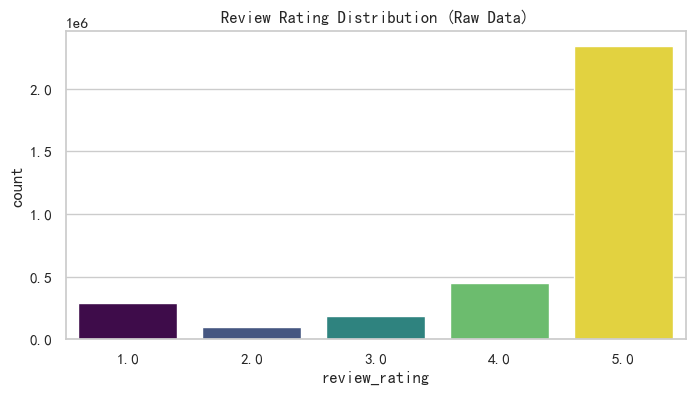

当前各评分数量:
 review_rating
1.0     288656
2.0      96163
3.0     183069
4.0     447760
5.0    2344840
Name: count, dtype: int64
5星保留目标数量: 1343280
CheckPoint C - App 1 训练集行数: 2358928


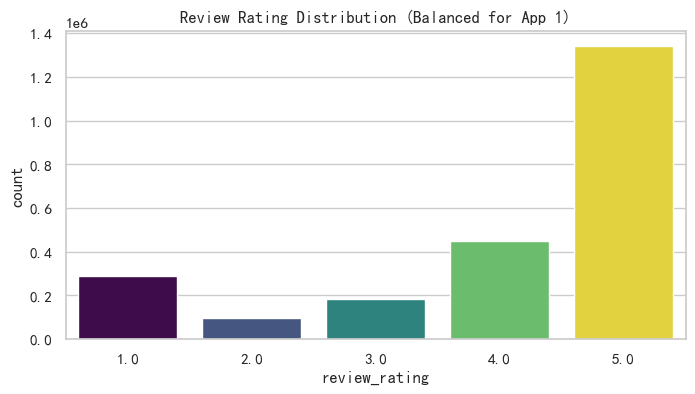

In [5]:
# ==========================================
# 4. 类别平衡 (Balancing for App 1)
# ==========================================
# 此时 df 已经拥有了 img_filenames，且包含所有图片信息

print("\n[Step 3] Balancing Dataset for App 1...")

# 绘制原始分布 (使用 review_rating)
plt.figure(figsize=(8, 4))
sns.countplot(x='review_rating', hue='review_rating', data=df, palette='viridis', legend=False)
plt.title('Review Rating Distribution (Raw Data)')
plt.show()

# 统计分布
rating_counts = df['review_rating'].value_counts().sort_index()
print("当前各评分数量:\n", rating_counts)

# 欠采样策略 (5星保留次大类别的3倍)
target_max_count = int(rating_counts.drop(5.0).max() * 3)
print(f"5星保留目标数量: {target_max_count}")

balanced_df_list = []
for rating, group in df.groupby('review_rating'):
    if rating == 5.0 and len(group) > target_max_count:
        balanced_df_list.append(group.sample(n=target_max_count, random_state=42))
    else:
        balanced_df_list.append(group)

df_balanced = pd.concat(balanced_df_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Checkpoint C: 平衡后
print(f"CheckPoint C - App 1 训练集行数: {len(df_balanced)}")

plt.figure(figsize=(8, 4))
sns.countplot(x='review_rating', hue='review_rating', data=df_balanced, palette='viridis', legend=False)
plt.title('Review Rating Distribution (Balanced for App 1)')
plt.show()

## 5. 数据集划分与保存 (Splitting & Saving)
**目标:** 创建模型训练所需的最终产物。
* **分层划分 (Stratified Split):** 确保训练集、验证集和测试集共享相同的类别分布比例。
* **比例:** 80% 训练 / 10% 验证 / 10% 测试。
* **输出:** 保存为 `.ftr` (Feather) 文件，以便在训练循环中实现极速加载。

In [6]:
# ==========================================
# 5. 数据集划分与保存 (Splitting & Saving)
# ==========================================

print("\n[Step 4] Splitting & Saving Data...")

# 划分 Train/Temp，注意 stratify 使用 review_rating
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['review_rating']
)

# 划分 Val/Test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['review_rating']
)

print(f"Train Set: {len(train_df)}")
print(f"Val Set:   {len(val_df)}")
print(f"Test Set:  {len(test_df)}")

# 保存
train_path = os.path.join(get_unc_path(DATA_OUTPUT_DIR), 'App1_Data_Train.ftr')
val_path = os.path.join(get_unc_path(DATA_OUTPUT_DIR), 'App1_Data_Val.ftr')
test_path = os.path.join(get_unc_path(DATA_OUTPUT_DIR), 'App1_Data_Test.ftr')

train_df.reset_index(drop=True).to_feather(train_path)
val_df.reset_index(drop=True).to_feather(val_path)
test_df.reset_index(drop=True).to_feather(test_path)

print(f"保存完成:\n - {train_path}\n - {val_path}\n - {test_path}")
print("\nDone!")


[Step 4] Splitting & Saving Data...
Train Set: 1887142
Val Set:   235893
Test Set:  235893
保存完成:
 - \\?\e:\05_YZH_DS\02_Monash_DS\2024_S2_FIT5196_Data wrangling\5. assessments\FIT5196 assignment 1\04_github_submission\2024-07-Google-Map-Review-Analysis-and-Machine-Learning\01_data\04_data_for_app1\App1_Data_Train.ftr
 - \\?\e:\05_YZH_DS\02_Monash_DS\2024_S2_FIT5196_Data wrangling\5. assessments\FIT5196 assignment 1\04_github_submission\2024-07-Google-Map-Review-Analysis-and-Machine-Learning\01_data\04_data_for_app1\App1_Data_Val.ftr
 - \\?\e:\05_YZH_DS\02_Monash_DS\2024_S2_FIT5196_Data wrangling\5. assessments\FIT5196 assignment 1\04_github_submission\2024-07-Google-Map-Review-Analysis-and-Machine-Learning\01_data\04_data_for_app1\App1_Data_Test.ftr

Done!


---
# END